tr_images & tr_targets:
	X - torch.Size([60000, 28, 28])
	Y - torch.Size([60000])
	Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


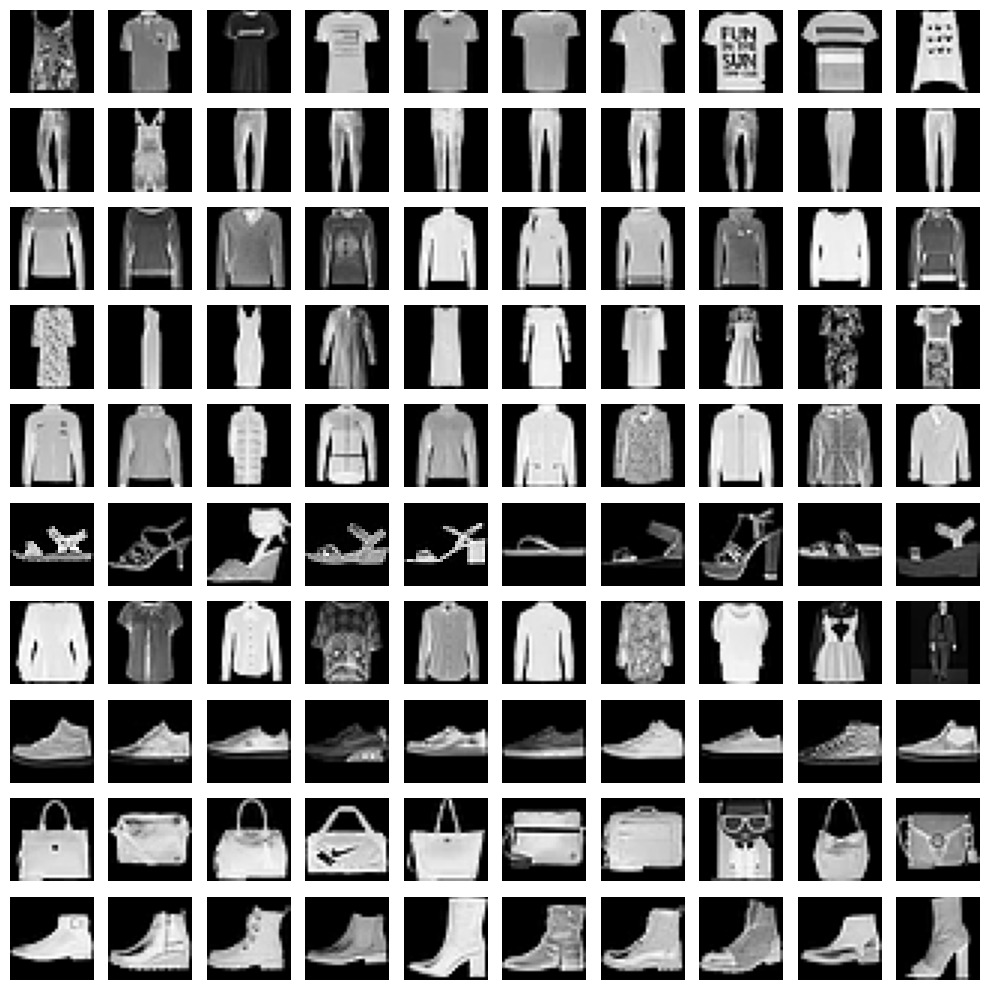

In [1]:
from torchvision import datasets
import torch

data_folder = '~/data/FMNIST'  # thư mục lưu dataset

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

unique_values = tr_targets.unique()

print(f'tr_images & tr_targets:\n\tX - {tr_images.shape}\n\tY - {tr_targets.shape}\n\tY - Unique Values : {unique_values}')
print(f'TASK:\n\t{len(unique_values)} class Classification')
print(f'UNIQUE CLASSES:\n\t{fmnist.classes}')

import matplotlib.pyplot as plt
import numpy as np
import torch

# số hàng và cột hiển thị
R, C = len(tr_targets.unique()), 10

fig, ax = plt.subplots(R, C, figsize=(10, 10))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')

        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]

        plot_cell.imshow(x, cmap='gray')

plt.tight_layout()
plt.show()


Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


C:\Users\US\AppData\Local\Temp\ipykernel_12856\2323882261.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


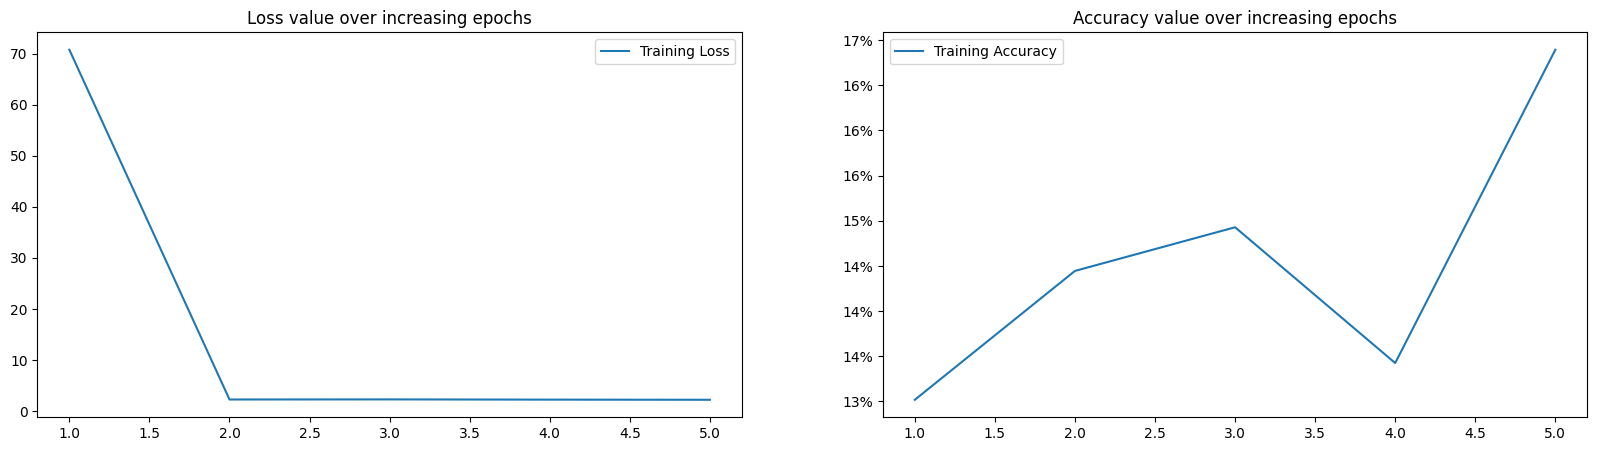

In [2]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.optim import SGD

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl


# Model
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train one batch
def train_batch(x, y, model, optimizer, loss_fn):
    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    return batch_loss.item()


# Accuracy
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)

    _, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


# Training
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses = []
accuracies = []

for epoch in range(5):

    print("Epoch:", epoch + 1)

    epoch_losses = []
    epoch_accuracies = []

    for batch in trn_dl:
        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        epoch_losses.append(batch_loss)

    epoch_loss = np.mean(epoch_losses)

    for batch in trn_dl:
        x, y = batch

        is_correct = accuracy(x, y, model)

        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)


# Plot result
epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, label="Training Loss")
plt.legend()

plt.subplot(122)
plt.title("Accuracy value over increasing epochs")
plt.plot(epochs, accuracies, label="Training Accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


C:\Users\US\AppData\Local\Temp\ipykernel_12856\654976179.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


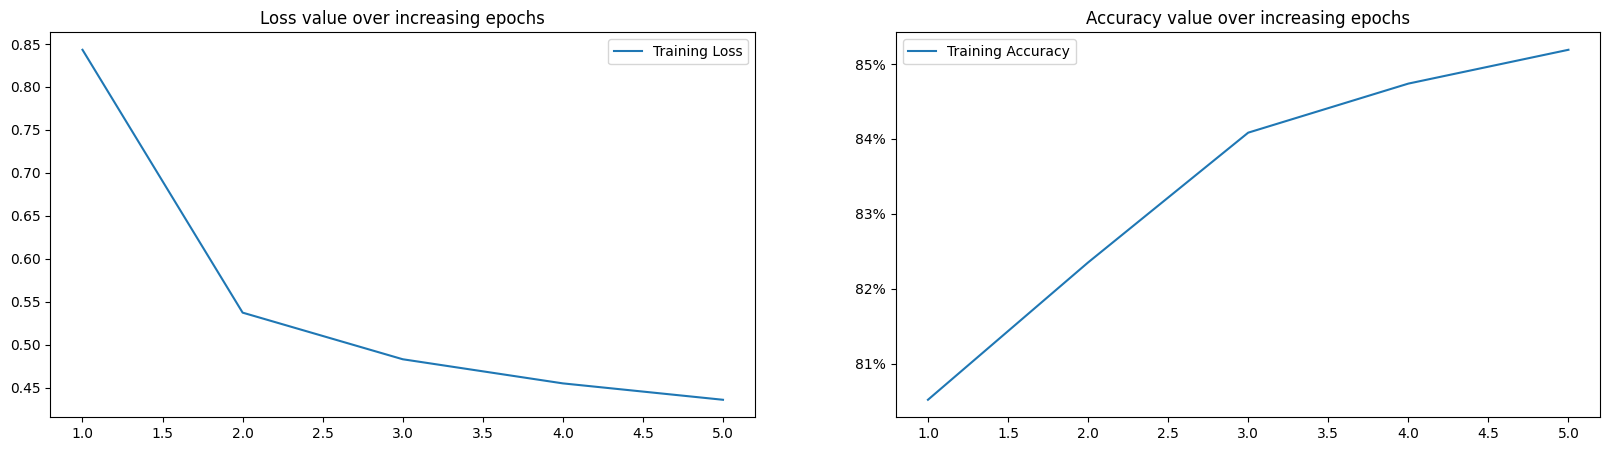

In [3]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import SGD

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl


# Model
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train one batch
def train_batch(x, y, model, optimizer, loss_fn):
    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    return batch_loss.item()


# Accuracy
def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():

        prediction = model(x)

        _, argmaxes = prediction.max(-1)

        is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


# Training
trn_dl = get_data()

model, loss_fn, optimizer = get_model()

losses = []
accuracies = []

for epoch in range(5):

    print("Epoch:", epoch + 1)

    epoch_losses = []
    epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        epoch_losses.append(batch_loss)

    epoch_loss = np.mean(epoch_losses)

    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(x, y, model)

        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)


# Plot results
epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, label="Training Loss")
plt.legend()

plt.subplot(122)
plt.title("Accuracy value over increasing epochs")
plt.plot(epochs, accuracies, label="Training Accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


C:\Users\US\AppData\Local\Temp\ipykernel_12856\72952611.py:206: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


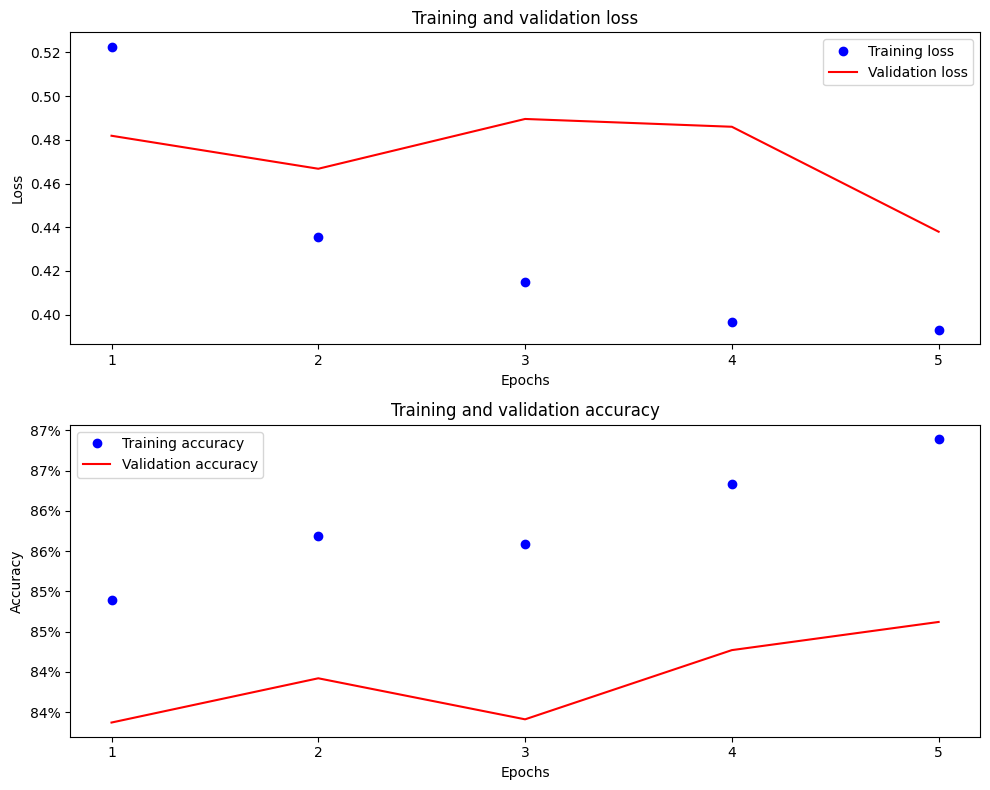

In [4]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# Model
def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train batch
def train_batch(x, y, model, optimizer, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    return batch_loss.item()


# Accuracy
def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():

        prediction = model(x)

        _, argmaxes = prediction.max(-1)

        is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


# Validation loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    prediction = model(x)

    v_loss = loss_fn(prediction, y)

    return v_loss.item()


# Prepare data
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


# Training loop
for epoch in range(5):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(x, y, model)

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(x, y, model)

        validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# Plot results
epochs = np.arange(5) + 1

plt.figure(figsize=(10, 8))

plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title("Training and validation loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.grid(False)

plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title("Training and validation accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


C:\Users\US\AppData\Local\Temp\ipykernel_12856\1038691311.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


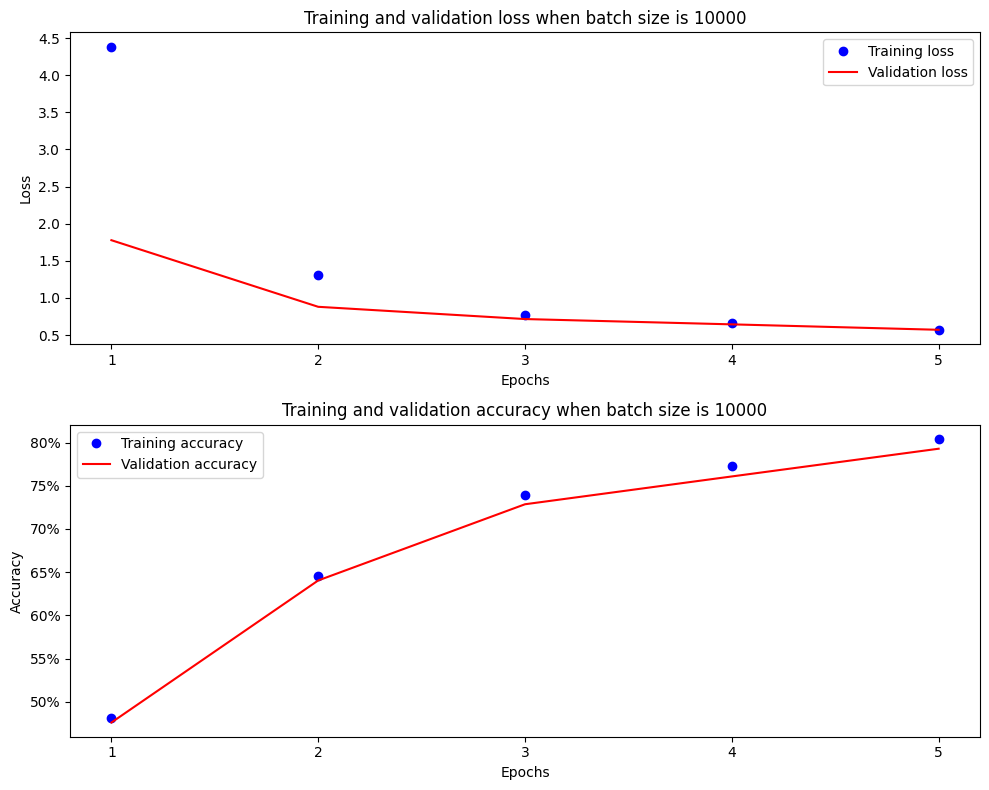

In [5]:
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


for epoch in range(5):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(x, y, model)

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(x, y, model)

        validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10,8))

plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss when batch size is 10000')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.grid(False)

plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy when batch size is 10000')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10


C:\Users\US\AppData\Local\Temp\ipykernel_12856\4484015.py:207: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


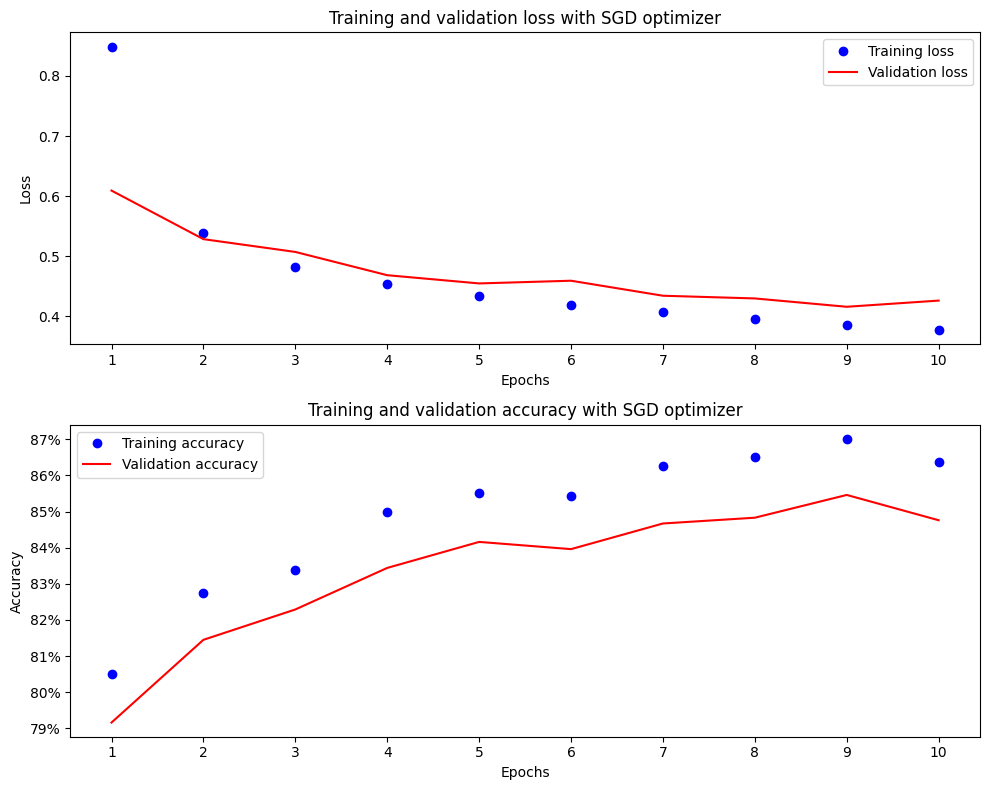

In [6]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# Model
def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train one batch
def train_batch(x, y, model, optimizer, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    optimizer.step()

    optimizer.zero_grad()

    return batch_loss.item()


# Accuracy
def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():

        prediction = model(x)

        _, argmaxes = prediction.max(-1)

        is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


# Validation loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    prediction = model(x)

    v_loss = loss_fn(prediction, y)

    return v_loss.item()


# Prepare data
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


# Training loop
for epoch in range(10):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(x, y, model)

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(x, y, model)

        validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# Plot results
epochs = np.arange(10) + 1

plt.figure(figsize=(10,8))

plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title("Training and validation loss with SGD optimizer")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.grid(False)


plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title("Training and validation accuracy with SGD optimizer")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.show()

0
1
2
3
4
5
6
7
8
9


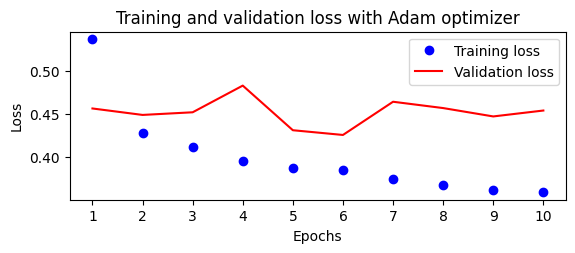

C:\Users\US\AppData\Local\Temp\ipykernel_12856\231484696.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


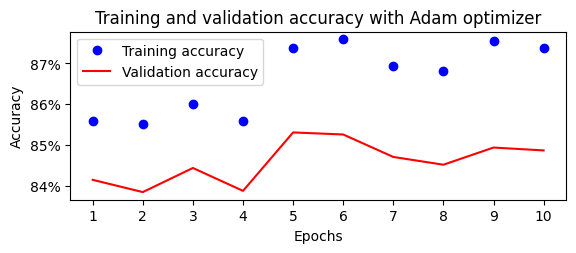

In [8]:
from torch.optim import SGD, Adam

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):

    print(epoch)

    train_epoch_losses = []
    train_epoch_accuracies = []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        is_correct = accuracy(x, y, model)

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch

        val_is_correct = accuracy(x, y, model)

        validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(10) + 1

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with Adam optimizer')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.grid(False)

plt.show()


plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with Adam optimizer')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.grid(False)

plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


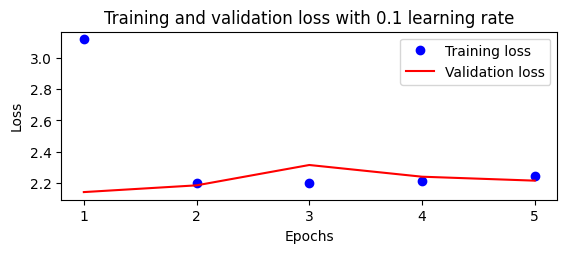

C:\Users\US\AppData\Local\Temp\ipykernel_12856\2523892180.py:207: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


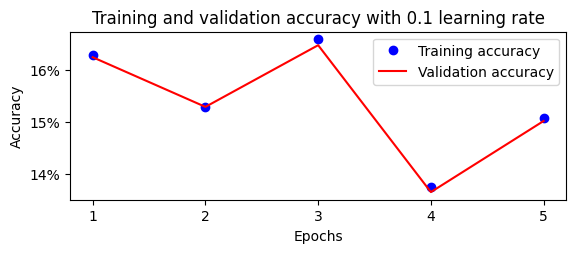

In [9]:
from torchvision import datasets
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import SGD, Adam

# device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load dataset
data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets


# dataset class
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# model
def get_model():

    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    # high learning rate
    optimizer = Adam(model.parameters(), lr=1e-1)

    return model, loss_fn, optimizer


# train batch
def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    opt.step()

    opt.zero_grad()

    return batch_loss.item()


# accuracy
def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():

        prediction = model(x)

        _, argmaxes = prediction.max(-1)

        is_correct = argmaxes == y

        return is_correct.cpu().numpy().tolist()


# dataloader
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# validation loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    prediction = model(x)

    loss = loss_fn(prediction, y)

    return loss.item()


# load data and model
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


# training loop
for epoch in range(5):

    print("Epoch:", epoch+1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(x, y, model)

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(x, y, model)

        validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# epochs
epochs = np.arange(5) + 1


# plot loss
plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.1 learning rate')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)

plt.show()


# plot accuracy
plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.1 learning rate')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid(False)

plt.show()

In [ ]:
45